In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ds_salaries.csv')

df.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [4]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [5]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [12]:
df['salary_in_usd'].mean().__round__(2)

np.float64(137570.39)

In [11]:
df.groupby('experience_level')['salary_in_usd'].mean().__round__(2)

experience_level
EN     78546.28
EX    194930.93
MI    104525.94
SE    153051.07
Name: salary_in_usd, dtype: float64

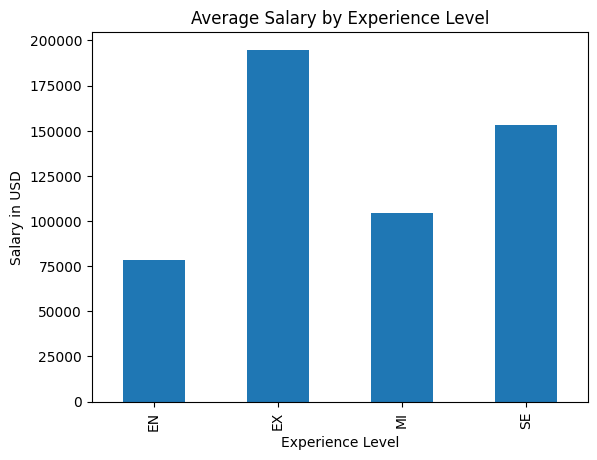

In [15]:
df.groupby('experience_level')['salary_in_usd'].mean().plot(kind='bar')

plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD')

plt.show()

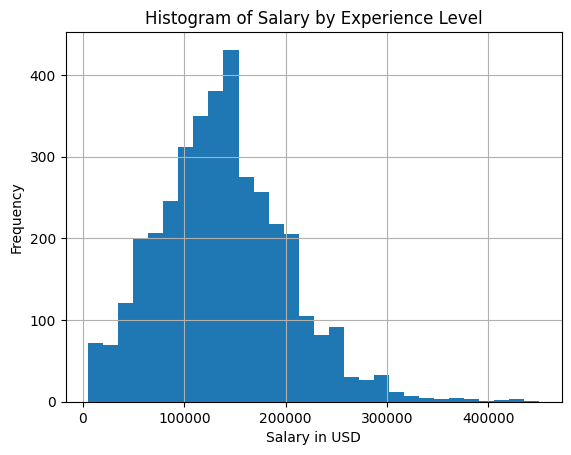

In [16]:
df ['salary_in_usd'].hist(bins=30)

plt.title('Histogram of Salary by Experience Level')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')

plt.show()

In [19]:
df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(10).__round__()

company_location
IL    271446.0
PR    167500.0
US    151822.0
RU    140333.0
CA    131918.0
NZ    125000.0
BA    120000.0
IE    114943.0
JP    114127.0
SE    105000.0
Name: salary_in_usd, dtype: float64

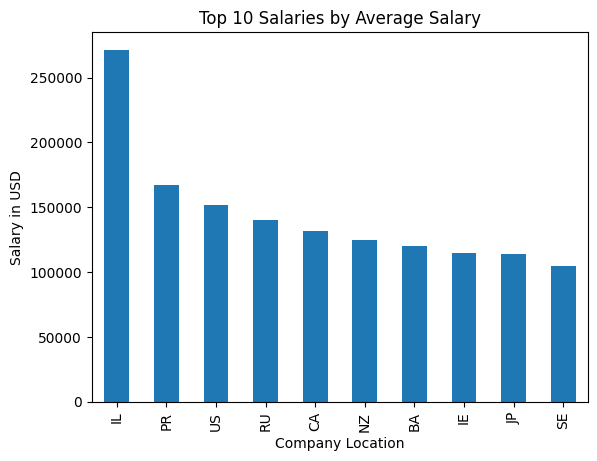

In [24]:
top_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar')

plt.title('Top 10 Salaries by Average Salary')
plt.xlabel('Company Location')
plt.ylabel('Salary in USD')

plt.show()


In [32]:
df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

job_title
Data Science Tech Lead                375000.000000
Cloud Data Architect                  250000.000000
Data Lead                             212500.000000
Data Analytics Lead                   211254.500000
Principal Data Scientist              198171.125000
Director of Data Science              195140.727273
Principal Data Engineer               192500.000000
Machine Learning Software Engineer    192420.000000
Data Science Manager                  191278.775862
Applied Scientist                     190264.482759
Name: salary_in_usd, dtype: float64

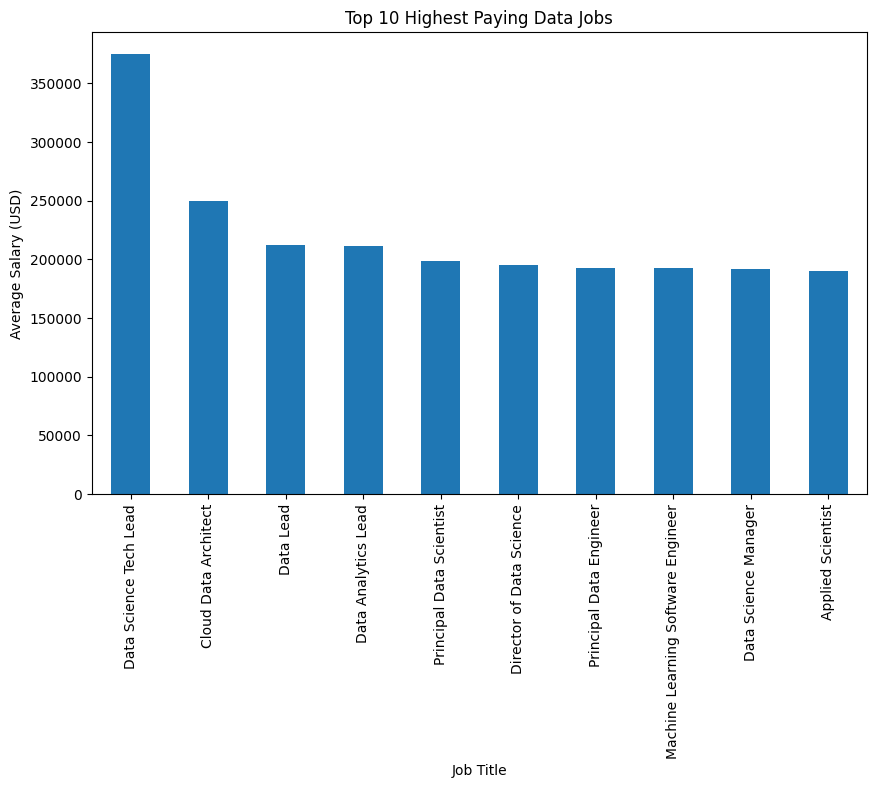

In [33]:
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_jobs.plot(kind='bar')

plt.title('Top 10 Highest Paying Data Jobs')
plt.xlabel('Job Title')
plt.ylabel('Average Salary (USD)')

plt.show()

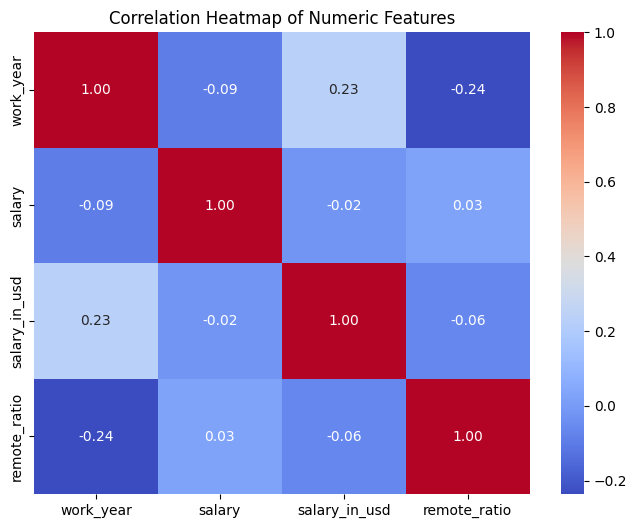

In [27]:
 # Correlation heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numeric Features')

plt.show()

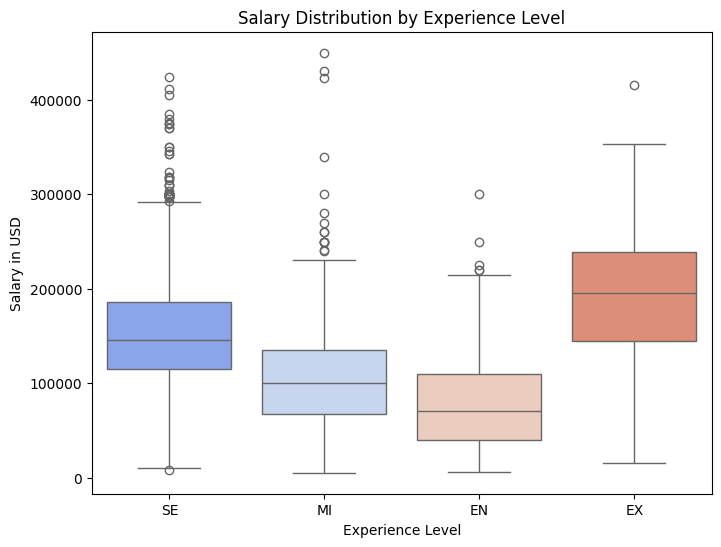

In [31]:
# Boxplot: Salary distribution by experience level

plt.figure(figsize=(8,6))

sns.boxplot(x='experience_level', y='salary_in_usd', hue='experience_level', data=df, palette='coolwarm', legend=False )

plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD')

plt.show()

Key Findings

- Senior specialists earn significantly higher salaries.
- Most high-paying data science jobs are located in specific countries.
- Remote work positions often offer competitive salaries compared to office roles.
- Salary distribution is skewed toward higher ranges.
- Salary increases significantly with experience level.
- Senior and Executive roles show higher salary ranges and more variability.